In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths (run from notebooks/)
base = Path("..")

phaseA_perq_path = base / "report/phaseA_report_perq.tsv"  # retrieval
phaseB_perq_path = base / "report/phaseB_report_perq.tsv"  # generation

phaseA_perq = pd.read_csv(phaseA_perq_path, sep="\t")
phaseB_perq = pd.read_csv(phaseB_perq_path, sep="\t")

# Align on split + question_id
perq_merged = phaseA_perq.merge(
    phaseB_perq,
    on=["split", "question_id"],
    how="inner",
    suffixes=("_retr", "_gen"),
)

# Select retrieval d_MAP and generation recall metrics
retr_col = "d_MAP_retr" if "d_MAP_retr" in perq_merged.columns else "d_MAP"
r2_col = "R_2_Rec"
su4_col = "R_SU4_Rec"

# Clean and drop rows with missing values in the used columns
valid = (
    perq_merged[[retr_col, r2_col, su4_col]]
    .replace({"NA": np.nan})
    .astype(float)
    .dropna()
)

print(f"Valid rows for correlation: {len(valid)}")

corr_r2 = valid[[retr_col, r2_col]].corr(method="pearson").iloc[0, 1]
corr_su4 = valid[[retr_col, su4_col]].corr(method="pearson").iloc[0, 1]

print("Pearson corr(d_MAP, R_2_Rec):  ", corr_r2)
print("Pearson corr(d_MAP, R_SU4_Rec):", corr_su4)

valid[[retr_col, r2_col, su4_col]].describe()

Valid rows for correlation: 699
Pearson corr(d_MAP, R_2_Rec):   0.23840811161910744
Pearson corr(d_MAP, R_SU4_Rec): 0.24161286126448453


,d_MAP,R_2_Rec,R_SU4_Rec
count,699.000000,699.000000,699.000000
mean,0.338134,0.242592,0.268912
std,0.335411,0.237795,0.224677
min,0.000000,0.000000,0.000000
25%,0.050000,0.067647,0.107246
50%,0.234444,0.166667,0.200000
75%,0.514722,0.346327,0.364358
max,1.000000,1.000000,1.000000


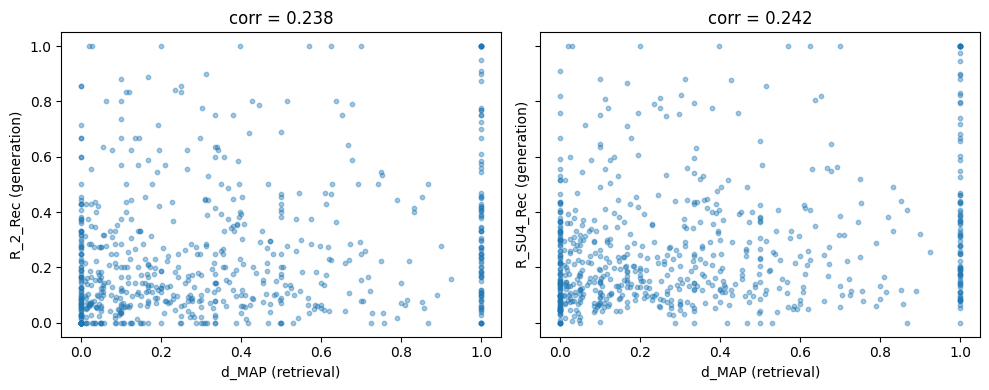

In [2]:
# Quick scatter plots: retrieval d_MAP vs generation recall

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].scatter(valid[retr_col], valid[r2_col], alpha=0.4, s=10)
axes[0].set_xlabel("d_MAP (retrieval)")
axes[0].set_ylabel("R_2_Rec (generation)")
axes[0].set_title(f"corr = {corr_r2:.3f}")

axes[1].scatter(valid[retr_col], valid[su4_col], alpha=0.4, s=10)
axes[1].set_xlabel("d_MAP (retrieval)")
axes[1].set_ylabel("R_SU4_Rec (generation)")
axes[1].set_title(f"corr = {corr_su4:.3f}")

plt.tight_layout()
plt.show()

In [4]:
# Compare generation metrics across ground-truth temperatures

from pathlib import Path
import pandas as pd

# Base dir is already defined as `base = Path("..")` above
gt_base = base / "report/groundtruth"

conditions = {
    "temp_0.0": gt_base / "0.0/phaseB_report.tsv",
    "temp_0.3": gt_base / "0.3/phaseB_report.tsv",
    "temp_0.8": gt_base / "default/phaseB_report.tsv",
}

metrics = ["YN_Acc", "F_MRR", "L_F1", "R_2_Rec", "R_SU4_Rec"]

# Load all three reports
reports = {
    name: pd.read_csv(path, sep="\t")
    for name, path in conditions.items()
}

# 1) Overall summary (mean over all splits per condition)
summary_rows = []
for name, df in reports.items():
    row = {"condition": name}
    for m in metrics:
        # ensure numeric (in case of string columns)
        row[m] = pd.to_numeric(df[m], errors="coerce").mean()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("condition")
print("Overall mean metrics per condition (averaged over all splits):")
display(summary_df)

# 2) Detailed table: metrics per split and condition
long_rows = []
for name, df in reports.items():
    tmp = df[["split"] + metrics].copy()
    tmp["condition"] = name
    long_rows.append(tmp)

long_df = pd.concat(long_rows, ignore_index=True)
print("\nPer-split metrics for each condition:")
display(long_df)

Overall mean metrics per condition (averaged over all splits):


,YN_Acc,F_MRR,L_F1,R_2_Rec,R_SU4_Rec
condition,,,,,
temp_0.0,0.940176,0.498806,0.517660,0.325928,0.338202
temp_0.3,0.940176,0.499368,0.518879,0.323829,0.335359
temp_0.8,0.940176,0.498806,0.518268,0.326744,0.338859



Per-split metrics for each condition:


,split,YN_Acc,F_MRR,L_F1,R_2_Rec,R_SU4_Rec,condition
0,13B1_golden_answers,1.000000,0.493590,0.451023,0.326817,0.339897,temp_0.0
1,13B2_golden_answers,0.941176,0.518519,0.507038,0.393883,0.392359,temp_0.0
2,13B3_golden_answers,0.909091,0.450000,0.548267,0.299262,0.313963,temp_0.0
3,13B4_golden_answers,0.923077,0.590909,0.505992,0.257630,0.274323,temp_0.0
4,training14b_10pct_sample_answers,0.927536,0.441011,0.575977,0.352047,0.370466,temp_0.0
5,13B1_golden_answers,1.000000,0.493590,0.453094,0.333356,0.336309,temp_0.3
6,13B2_golden_answers,0.941176,0.518519,0.499961,0.373732,0.376570,temp_0.3
7,13B3_golden_answers,0.909091,0.450000,0.549985,0.293650,0.314302,temp_0.3
8,13B4_golden_answers,0.923077,0.590909,0.520355,0.262075,0.278317,temp_0.3
9,training14b_10pct_sample_answers,0.927536,0.443820,0.571001,0.356331,0.371296,temp_0.3


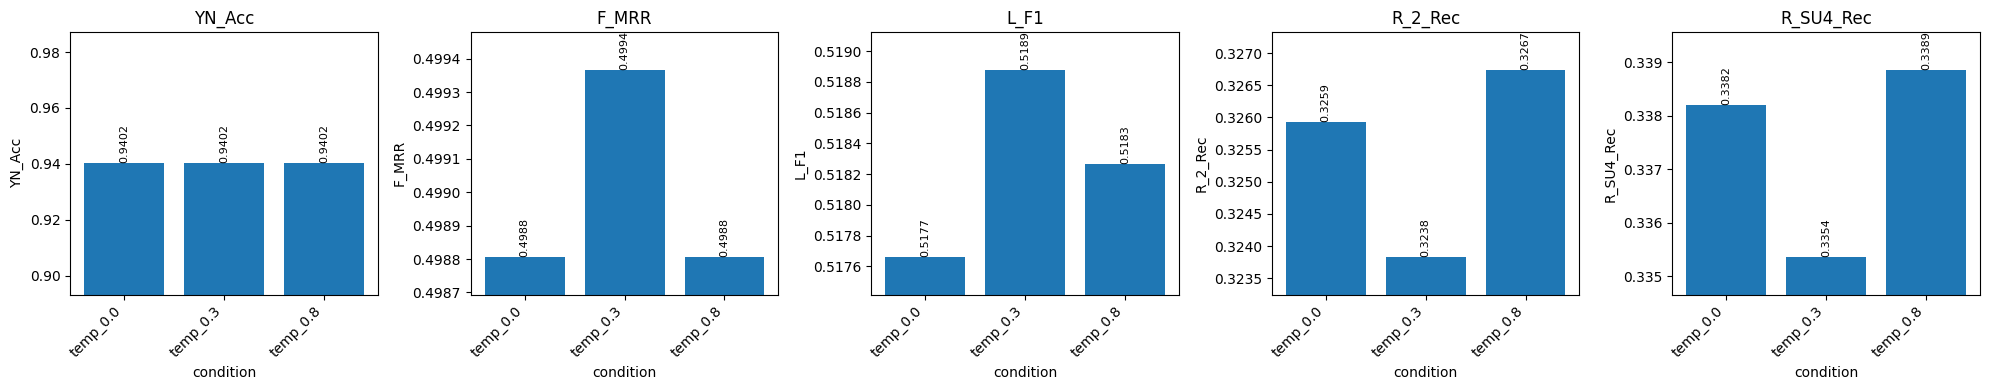

In [6]:
# Plot comparison of metrics across conditions (zoomed to small differences)

# We assume `summary_df` from the previous cell is available
# Rows: conditions, Columns: metrics

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=False)

if len(metrics) == 1:
    axes = [axes]

for ax, m in zip(axes, metrics):
    vals = summary_df[m].values
    x = np.arange(len(summary_df.index))

    # bar for each condition
    ax.bar(x, vals)
    ax.set_title(m)
    ax.set_xlabel("condition")
    ax.set_ylabel(m)
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df.index, rotation=45, ha="right")

    # Zoom y-axis around the data range so small differences are visible
    vmin, vmax = vals.min(), vals.max()
    rng = vmax - vmin
    if rng == 0:
        # all equal: just put a small band around the value
        pad = max(0.001, 0.05 * abs(vmin) if vmin != 0 else 0.01)
        ax.set_ylim(vmin - pad, vmax + pad)
    else:
        # add a bit of padding but keep focus on this narrow band
        pad = 0.2 * rng
        ax.set_ylim(max(0, vmin - pad), min(1.0, vmax + pad))

    # Annotate exact values on top of bars
    for xi, v in zip(x, vals):
        ax.text(xi, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

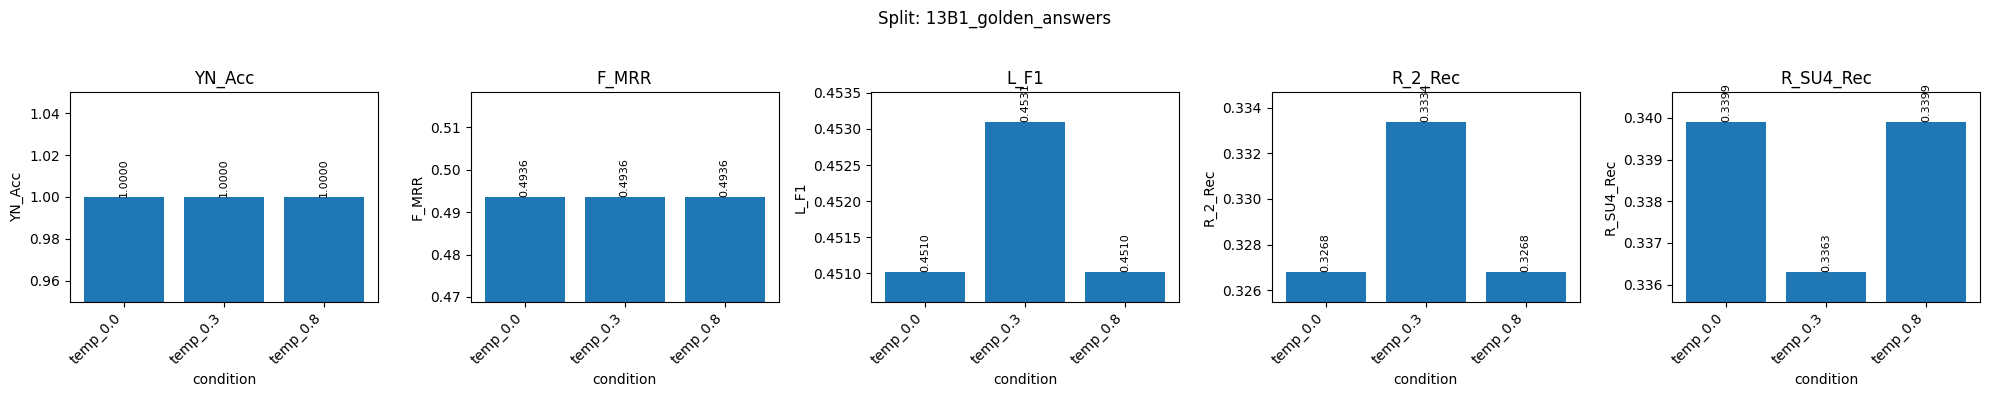

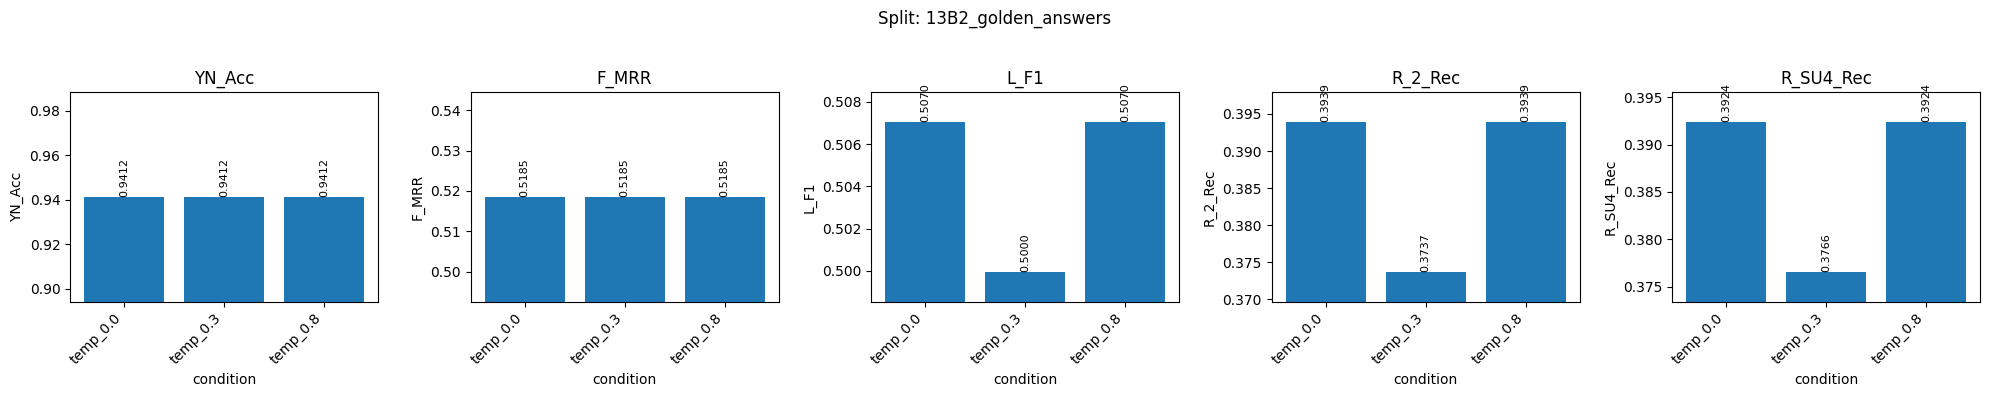

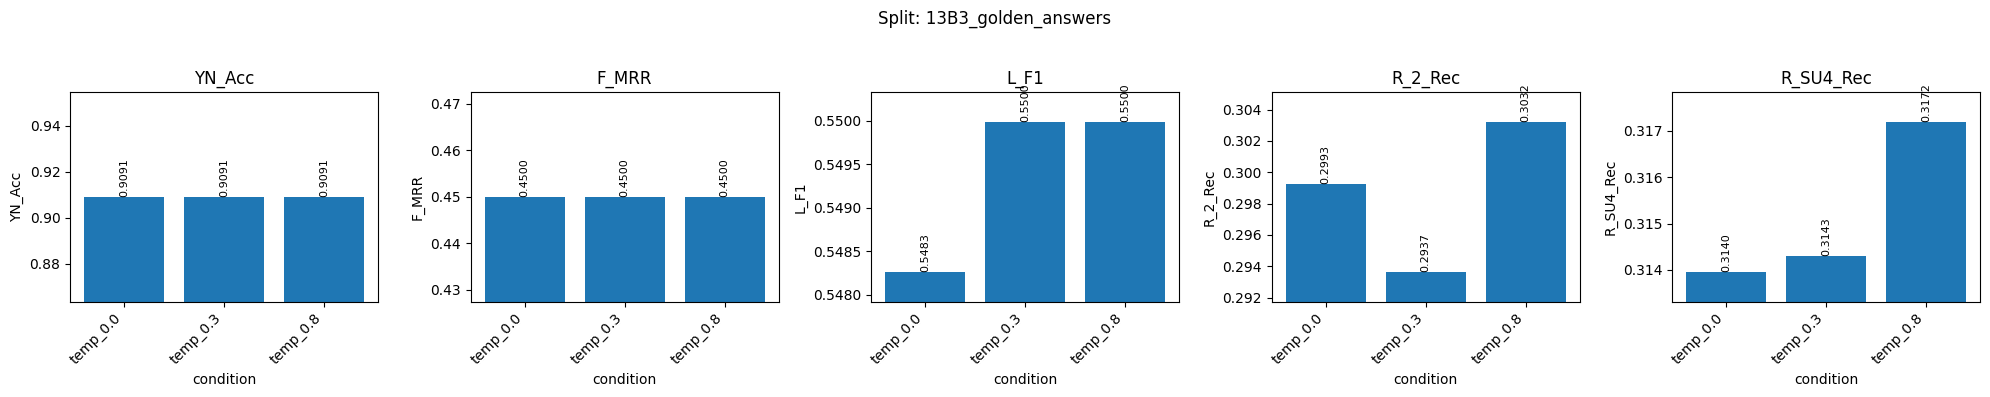

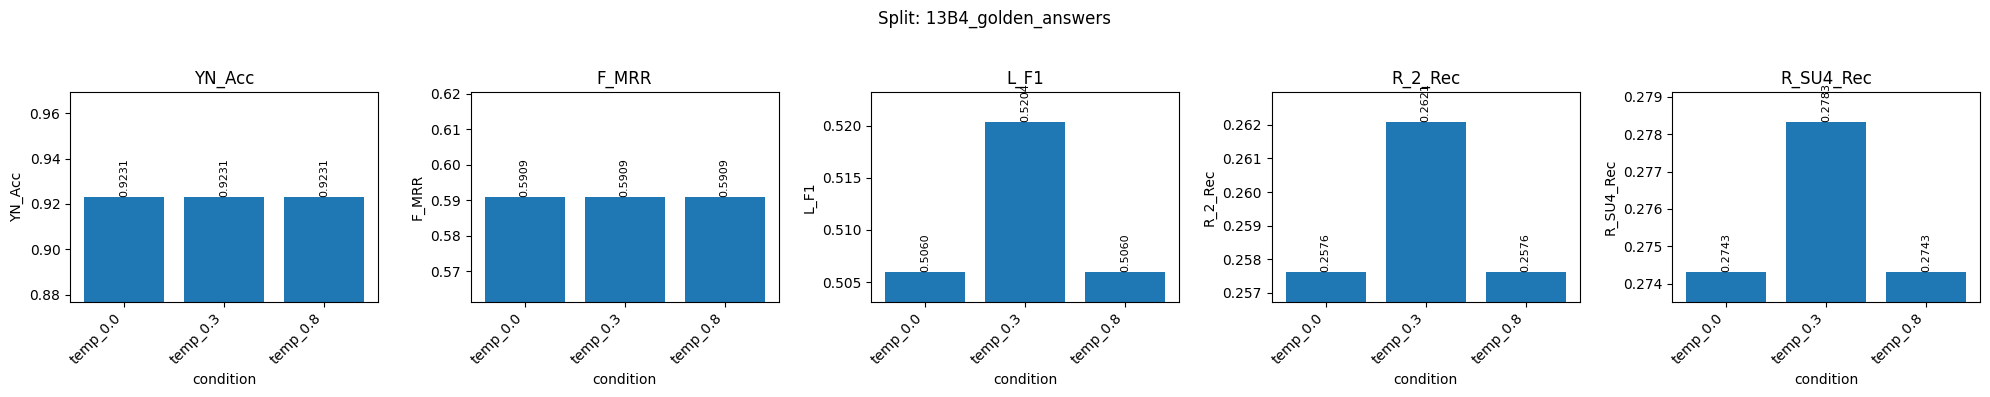

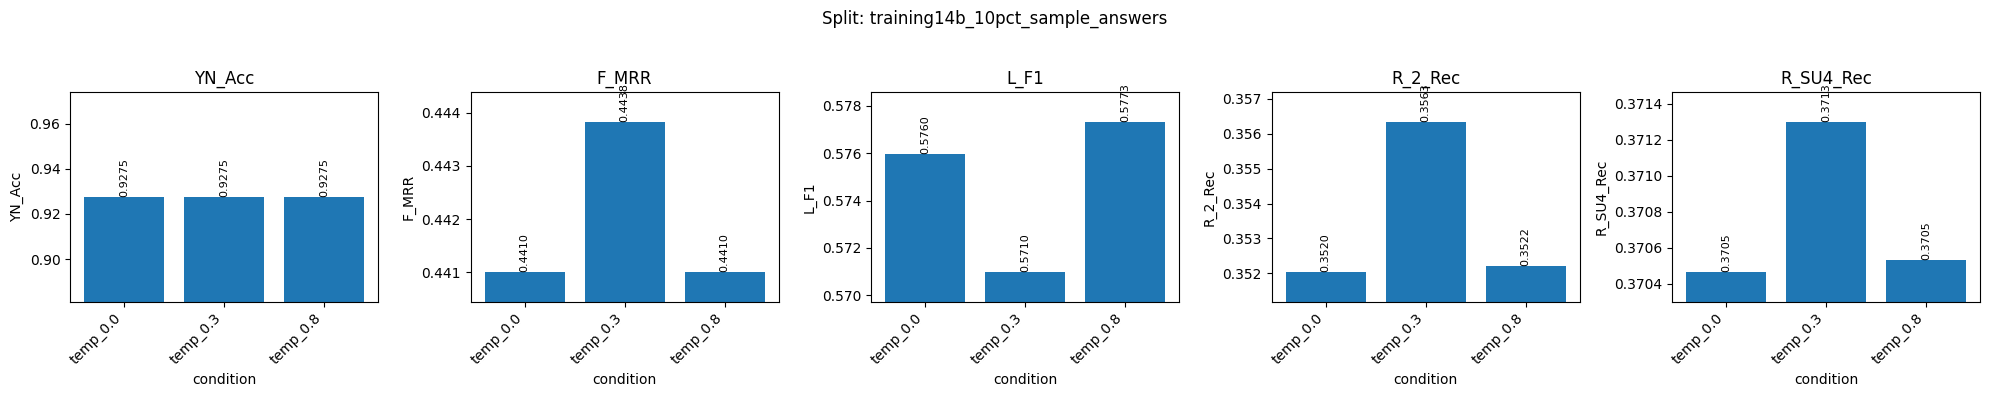

In [7]:
# Plot per-split comparison: for each split, metrics across conditions (zoomed)

# We assume `long_df` from the previous cell is available
# Columns: split, condition, metrics

splits = long_df["split"].unique()

for split in splits:
    df_s = long_df[long_df["split"] == split].set_index("condition")

    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=False)
    if len(metrics) == 1:
        axes = [axes]

    fig.suptitle(f"Split: {split}")

    for ax, m in zip(axes, metrics):
        vals = df_s[m].values
        conds = df_s.index.tolist()
        x = np.arange(len(conds))

        ax.bar(x, vals)
        ax.set_title(m)
        ax.set_xlabel("condition")
        ax.set_ylabel(m)
        ax.set_xticks(x)
        ax.set_xticklabels(conds, rotation=45, ha="right")

        # Zoom y-axis around the data range so small differences are visible
        vmin, vmax = vals.min(), vals.max()
        rng = vmax - vmin
        if rng == 0:
            pad = max(0.001, 0.05 * abs(vmin) if vmin != 0 else 0.01)
            ax.set_ylim(vmin - pad, vmax + pad)
        else:
            pad = 0.2 * rng
            ax.set_ylim(max(0, vmin - pad), min(1.0, vmax + pad))

        # Annotate exact values on top of bars
        for xi, v in zip(x, vals):
            ax.text(xi, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8, rotation=90)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()